# Lifecycle planning under mortality, regime-switching markets, and a retirement decision

A simplified but **real** lifecycle problem — the same shape that
financial-planning software solves, just with the second-order details
(taxes, multi-account allocations, social security) skipped for
clarity. This is the canonical "complex DP" that motivated bellgrid:
every primitive in the library gets used here, and the solution is
the recommended consumption / retirement / portfolio path for an agent
from age 25 to 100.

## Problem

At each age $t \in \{25, 26, \ldots, 99\}$ the agent observes
$(w_t, \tau_t, r_t)$ — current cash-on-hand, working/retired phase,
and economic regime — and chooses:

- **consumption** $c_t \in (0, w_t]$ (the no-borrowing constraint),
- **retire flag** $\rho_t \in \{0, 1\}$ (irreversible — once retired,
  stay retired),
- **equity share** $\alpha_t \in \{0, 0.2, 0.4, 0.6, 0.8, 1.0\}$.

**Wealth dynamics** (in real terms; we deflate by the regime's
inflation):

$$ w_{t+1} = (w_t - c_t)\,\frac{1 + \alpha_t r^e_t + (1 - \alpha_t) y_t}{1 + \pi_t}\;+\; \text{wage}(t+1)\,\mathbf{1}\{\tau_{t+1} = \text{working}\}, $$

where $r^e_t = \mu^e_t + \sigma^e Z_t$ is the (nominal) equity return,
$y_t$ is the regime's bond yield, and $\pi_t$ is the regime's inflation.

**Phase dynamics** are user-controlled and absorbing:

$$ \tau_{t+1} = \tau_t \;\vee\; \rho_t \quad\text{(once retired, stay retired).} $$

**Regime dynamics** are a 6-state Markov chain with a tridiagonal
mean-reverting matrix $P$ — the solver advances this automatically.

**Mortality + bequest.** This is what makes the problem a *life*-cycle.
In each period, with probability $1 - p_{\text{survive}}(t)$ the agent
dies; their remaining wealth is left as a bequest, which carries a
warm-glow utility. The Bellman recursion is therefore a **mixture**:

$$ V_t(s) = \max_{a} u(c_t, \tau_t) + \beta\,\mathbb{E}\!\Bigl[\,p_{\text{survive}}(t)\,V_{t+1}(s') + (1 - p_{\text{survive}}(t))\,\mathrm{Bequest}(s')\,\Bigr]. $$

Encoded in bellgrid as

- **Callable discount** $\beta(s, t) = \beta_0 \cdot p_{\text{survive}}(t)$
  — shrinks the continuation by survival probability.
- **Next-state-aware reward** $r(s, a, w, t, s') = u(c, \tau) +
  \beta_0 \cdot (1 - p_{\text{survive}}(t)) \cdot \mathrm{Bequest}(s')$
  — the bequest payoff fires per-period, weighted by death probability,
  and depends on the **next** wealth (not the current).

In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

# Make the helper modules in this directory importable.
sys.path.insert(0, str(Path.cwd()))

import mortality
import regimes
import utility
import wages

from bellgrid import (
    ContinuousAction,
    ContinuousState,
    DiscreteAction,
    DiscreteState,
    MarkovChain,
    Problem,
    simulate,
    solve,
)
from bellgrid.grids import RegularGrid, WarpedGrid
from bellgrid.shocks import Normal
from bellgrid.solvers import BackwardInduction

## Parameters

In [2]:
# Lifecycle horizon — ages 25 through 99 (decision dates), with the
# terminal V at age 100 given by Bequest(w).
MIN_AGE = 25
MAX_AGE = 100
beta_0 = 0.96                 # patience parameter (NOT mortality)
RISK_AVERSION = 3.0           # CRRA γ — moderate lifecycle-finance value

# Economic-regime parameters and Markov matrix.
REG = regimes.RegimeParameters()
P_REGIMES = regimes.tridiagonal_matrix(REG.n_regimes, p_stay=0.65)

# Wage profile — base peak $150k at age 50.
PEAK_WAGE = 150_000.0
PEAK_AGE = 50.0
MANDATORY_RETIREMENT_AGE = 70.0

# Wealth-grid range — $0 to $5M is comfortable for our peak income / β.
WEALTH_MIN = 1.0     # avoid log(0)
WEALTH_MAX = 5_000_000.0

# Action grids
N_CONSUME = 200
EQUITY_SHARE_VALUES = (0.0, 0.2, 0.4, 0.6, 0.8, 1.0)

# Initial state for forward simulation. ``INITIAL_WEALTH`` here is the
# agent's cash at the *start* of period 25 — i.e. savings carried in
# PLUS the wage just received this year. The transition adds wage(t+1)
# in every subsequent period, so under-counting the age-25 wage here
# would cause a spurious jump in the wealth trajectory between periods
# 25 and 26.
INITIAL_SAVINGS = 50_000.0
_initial_wage = wages.wage_at_age(
    torch.tensor(float(MIN_AGE), dtype=torch.float64),
    peak_wage=PEAK_WAGE, peak_age=PEAK_AGE,
    retirement_age=MANDATORY_RETIREMENT_AGE,
).item()
INITIAL_WEALTH = INITIAL_SAVINGS + _initial_wage
INITIAL_PHASE = 0         # working
INITIAL_REGIME = 2        # "normal" regime

print(f"Life expectancy at age {MIN_AGE}: "
      f"{mortality.life_expectancy(MIN_AGE):.1f} more years")
print(f"Initial cash at age {MIN_AGE}: "
      f"$${INITIAL_SAVINGS/1000:.0f}k savings + $${_initial_wage/1000:.0f}k wage "
      f"= $${INITIAL_WEALTH/1000:.0f}k")

Life expectancy at age 25: 53.9 more years
Initial cash at age 25: $$50k savings + $$86k wage = $$136k


## Mortality table and discount

`p_survive[t]` is the probability of surviving the year starting at
age `t`. We use it twice — as the **continuation discount**
$\beta_0 \cdot p_{\text{survive}}(t)$ and as the **bequest weight**
$1 - p_{\text{survive}}(t)$.

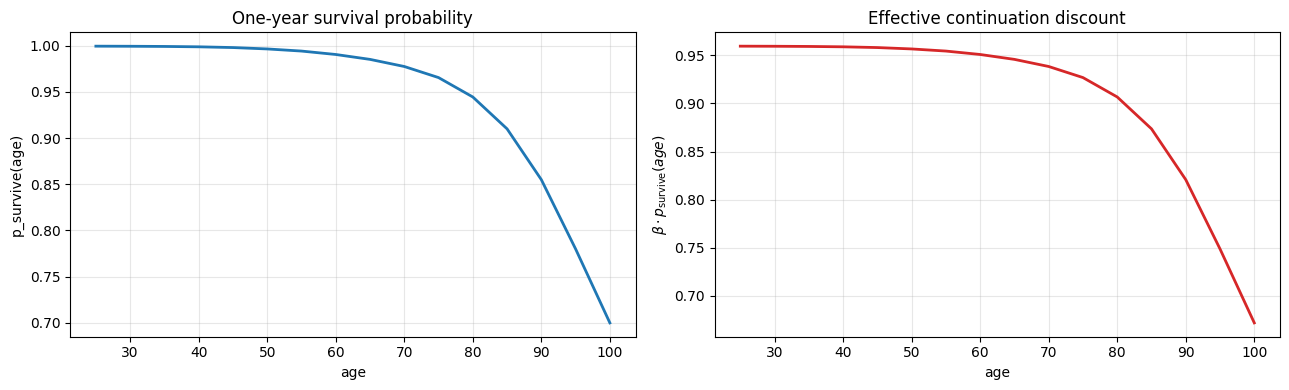

In [3]:
SURVIVAL_TABLE = mortality.survival_table(min_age=0, max_age=MAX_AGE + 5)


def discount(state, t):
    """β · p_survive(age). Callable discount in bellgrid's API."""
    dev = state["wealth"].device
    return beta_0 * SURVIVAL_TABLE.to(dev)[int(t)]


# Quick sanity plot of the survival schedule + the discount
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ages = np.arange(MIN_AGE, MAX_AGE + 1)
ax1.plot(ages, [SURVIVAL_TABLE[a].item() for a in ages], lw=2)
ax1.set_xlabel("age"); ax1.set_ylabel("p_survive(age)")
ax1.set_title("One-year survival probability")
ax1.grid(alpha=0.3)
ax2.plot(ages, [beta_0 * SURVIVAL_TABLE[a].item() for a in ages], lw=2, color="C3")
ax2.set_xlabel("age"); ax2.set_ylabel(r"$\beta \cdot p_\mathrm{survive}(age)$")
ax2.set_title("Effective continuation discount")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Utility functions

Two design choices worth a closer look.

### Consumption utility: CRRA with a normalised floor + log-barrier

Standard CRRA $u(c) = (c^{1-\gamma} - 1) / (1 - \gamma)$ has two issues
in finite-horizon DP: (a) it grows without bound in $c$, making the
value function numerically loose at high wealth, and (b) it goes to
$-\infty$ as $c \to 0$ for $\gamma > 1$ but only modestly, so a
discretized solver can pick "zero consumption" without much penalty.
Both are fixed by a renormalisation:

- **Above a subsistence floor** $\underline{c}$: rescale so
  $u(\underline{c}) = 0$ and $u(c_{\text{pref}}) = 1$. This makes the
  units of utility comparable across consumption and bequest.
- **Below the floor**: switch to a log-barrier
  $u(c) = s \cdot \log(c / \underline{c})$ which diverges to $-\infty$
  as $c \to 0^+$. The solver now actively avoids below-floor
  consumption when it has the option.

A small additive **leisure bonus** is added when the agent is retired
(`retirement_bonus = 0.1` in `utility.consumption_utility`). Too
small and nobody retires; too large and everyone retires immediately.
The model is fairly sensitive to this parameter — real lifecycle
software typically calibrates it.

### Bequest utility: warm-glow annuitisation

At death, the agent leaves bequest wealth $b$. Most lifecycle work
uses a "warm glow": the agent values the bequest *as if* it provided
consumption to a recipient. We annuitise $b$ over a fixed window of
`annuity_years = 20` years at a real discount of 0 (level annuity),
add it to a hypothetical recipient's baseline income, and take CRRA
utility of the resulting consumption stream relative to the baseline.

This produces three useful properties:
1. Bequest utility is on the **same numerical scale** as 20 years of
   consumption utility, so the trade-off "consume now vs leave behind"
   is properly weighted by the mortality probability.
2. **Diminishing returns** in $b$ — doubling a small bequest matters
   far more than doubling a huge one (the recipient's marginal
   utility falls as their consumption rises above the floor).
3. **Floor protection for the bequest** — a tiny bequest at low income
   is worth far more per dollar than a tiny bequest to a well-off
   recipient. (Set `baseline_income` low if you want the bequest to
   matter more.)

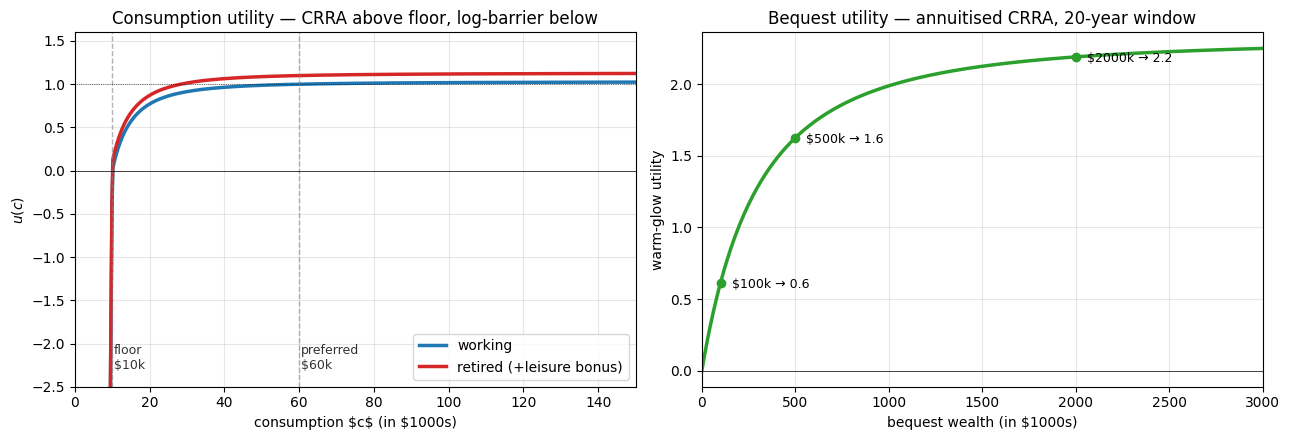

Relative scale (a year of preferred consumption is worth 1 util):
  20 years at preferred ($60k/yr): 20.0 util
  Bequest of $500k:                1.6 util
  Bequest of $2M:                  2.2 util


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Consumption utility ---------------------------------------------
# Linear x focused on the "useful" range (a bit below floor to well
# above preferred). The log-barrier dives off the bottom of the y-axis
# below the floor; the curvature above is the standard CRRA shape.
c_grid = torch.linspace(2_000.0, 150_000.0, 600, dtype=torch.float64)
u_working = utility.consumption_utility(c_grid, phase=torch.zeros_like(c_grid, dtype=torch.long), risk_aversion=RISK_AVERSION)
u_retired = utility.consumption_utility(c_grid, phase=torch.ones_like(c_grid, dtype=torch.long), risk_aversion=RISK_AVERSION)

ax1.plot(c_grid.numpy() / 1000, u_working.numpy(), lw=2.5, label="working")
ax1.plot(c_grid.numpy() / 1000, u_retired.numpy(), lw=2.5, color="C3", label="retired (+leisure bonus)")
ax1.set_xlim(0, 150)
ax1.set_ylim(-2.5, 1.6)
ax1.axvline(10, color="gray", ls="--", lw=1, alpha=0.6)
ax1.axvline(60, color="gray", ls="--", lw=1, alpha=0.6)
ax1.text(10.5, -2.3, "floor\n$10k", fontsize=9, alpha=0.8)
ax1.text(60.5, -2.3, "preferred\n$60k", fontsize=9, alpha=0.8)
ax1.axhline(0, color="black", lw=0.5)
ax1.axhline(1, color="black", lw=0.5, ls=":")
ax1.set_xlabel("consumption $c$ (in $1000s)")
ax1.set_ylabel("$u(c)$")
ax1.set_title("Consumption utility — CRRA above floor, log-barrier below")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- Bequest utility -------------------------------------------------
b_grid = torch.linspace(0.0, 3_000_000.0, 400, dtype=torch.float64)
b_u = utility.bequest_utility(b_grid, risk_aversion=RISK_AVERSION)

ax2.plot(b_grid.numpy() / 1000, b_u.numpy(), lw=2.5, color="C2")
ax2.axhline(0, color="black", lw=0.5)
ax2.set_xlim(0, 3000)
ax2.set_xlabel("bequest wealth (in $1000s)")
ax2.set_ylabel("warm-glow utility")
ax2.set_title("Bequest utility — annuitised CRRA, 20-year window")
ax2.grid(alpha=0.3)
for b_ref in (100_000, 500_000, 2_000_000):
    u_ref = utility.bequest_utility(torch.tensor(b_ref, dtype=torch.float64), risk_aversion=RISK_AVERSION).item()
    ax2.plot(b_ref / 1000, u_ref, "o", color="C2", markersize=6)
    ax2.annotate(
        f"${b_ref/1000:.0f}k → {u_ref:.1f}",
        xy=(b_ref / 1000, u_ref),
        xytext=(8, -4), textcoords="offset points", fontsize=9,
    )
plt.tight_layout()
plt.show()

print("Relative scale (a year of preferred consumption is worth 1 util):")
print(f"  20 years at preferred ($60k/yr): {20.0:.1f} util")
print(f"  Bequest of $500k:                "
      f"{utility.bequest_utility(torch.tensor(500_000.0), risk_aversion=RISK_AVERSION).item():.1f} util")
print(f"  Bequest of $2M:                  "
      f"{utility.bequest_utility(torch.tensor(2_000_000.0), risk_aversion=RISK_AVERSION).item():.1f} util")

## Bellgrid problem

**State**:
- `wealth`: `ContinuousState` on `[1, 5_000_000]`, `asinh`-warped so
  the grid is dense near zero (where the consumption decision has the
  most curvature) and sparse at the top.
- `phase`: `DiscreteState(n=2)` — `0 = working`, `1 = retired`. User-
  controlled dynamics: irreversible from working to retired.
- `regime`: `MarkovChain(n=6)` — the economic regime. Solver advances
  it via the tridiagonal matrix.

**Actions**:
- `consume`: `ContinuousAction` with `bounds=(1.0, "wealth")`. State-
  dependent upper bound — can't consume more than cash on hand.
- `retire`: `DiscreteAction(n=2)`. Only effective from the working
  phase; once `retire=1` you're retired forever.
- `equity_share`: `DiscreteAction(n=6)` — six allocations from
  all-bonds to all-equity.

**Shocks**: one `Normal` equity-return shock (standardised; we scale
by the regime's equity vol inside `transition`).

In [5]:
# Pre-compute wage at every relevant age, on the right dtype / device.
# wages.wage_at_age expects a tensor; build the lookup table once.
wage_table = wages.wage_at_age(
    torch.arange(0, MAX_AGE + 5, dtype=torch.float64),
    peak_wage=PEAK_WAGE,
    peak_age=PEAK_AGE,
    retirement_age=MANDATORY_RETIREMENT_AGE,
)


# Module-level reference tensors are on CPU; we .to(device) on first use
# from each closure (a no-op once already there). Captures the device
# from the input state at call time so the same problem definition works
# on either CPU or CUDA.
yields_t = torch.tensor(REG.yields, dtype=torch.float64)
infl_t = torch.tensor(REG.inflation, dtype=torch.float64)
eq_mean_t = torch.tensor(REG.equity_means, dtype=torch.float64)
equity_vol = REG.equity_vol
equity_share_t = torch.tensor(EQUITY_SHARE_VALUES, dtype=torch.float64)


def _wage_at(age_int: int, phase: torch.Tensor) -> torch.Tensor:
    """Wage paid at the start of period ``age_int`` if not retired.

    Device-aware: indexes the table on the same device as ``phase``.
    """
    table = wage_table.to(phase.device)
    working = (phase == 0).to(torch.float64)
    return table[age_int] * working


def transition(state, action, shock, t):
    """
    next_wealth = (cash - c) · real_portfolio_return + next_wage
    next_phase  = absorbing(current phase, retire decision)
    """
    cash = state["wealth"]
    phase = state["phase"]
    regime = state["regime"]
    consume = action["consume"]
    retire_now = action["retire"]
    eq_idx = action["equity_share"]

    dev = cash.device
    equity_w = equity_share_t.to(dev)[eq_idx]
    y = yields_t.to(dev)[regime]
    pi = infl_t.to(dev)[regime]
    mu_e = eq_mean_t.to(dev)[regime]

    equity_ret = mu_e + equity_vol * shock["z"]
    nom_port_ret = equity_w * equity_ret + (1.0 - equity_w) * y
    real_ret = (1.0 + nom_port_ret) / (1.0 + pi) - 1.0

    savings = torch.clamp((cash - consume) * (1.0 + real_ret), min=0.0)

    next_phase = torch.where(
        (phase == 0) & (retire_now == 0),
        torch.zeros_like(phase),
        torch.ones_like(phase),
    )

    next_age = int(t) + 1
    next_wage = _wage_at(next_age, next_phase)
    next_cash = savings + next_wage
    return {"wealth": next_cash, "phase": next_phase}


def reward(state, action, shock, t, next_state):
    """Per-period reward = u(c, phase) + β·(1−p_survive(t))·Bequest(next_state).

    Bequest payoff fires every period weighted by death probability —
    not just at the post-horizon boundary. Callable-discount +
    next-state-aware-reward encode the mixture exactly.
    """
    age = int(t)
    dev = state["wealth"].device
    p_survive_now = SURVIVAL_TABLE.to(dev)[age]

    u = utility.consumption_utility(
        action["consume"], state["phase"], risk_aversion=RISK_AVERSION,
    )

    next_age = age + 1
    next_wage = _wage_at(next_age, next_state["phase"])
    bequest_amount = next_state["wealth"] - next_wage
    bequest_u = utility.bequest_utility(bequest_amount, risk_aversion=RISK_AVERSION)

    return u + beta_0 * (1.0 - p_survive_now) * bequest_u


def terminal_reward(state):
    """At age MAX_AGE all remaining wealth becomes a bequest."""
    return utility.bequest_utility(state["wealth"], risk_aversion=RISK_AVERSION)

## Build and solve

In [6]:
problem = Problem(
    states=[
        ContinuousState("wealth", warp="asinh", range=(WEALTH_MIN, WEALTH_MAX)),
        DiscreteState("phase", n=2, labels=("working", "retired")),
        MarkovChain("regime", matrix=P_REGIMES, labels=REG.labels),
    ],
    actions=[
        ContinuousAction("consume", bounds=(1.0, "wealth")),
        DiscreteAction("retire", n=2, labels=("continue", "retire")),
        DiscreteAction("equity_share", n=len(EQUITY_SHARE_VALUES)),
    ],
    transition=transition,
    reward=reward,
    shocks=[Normal("z", sigma=1.0)],
    horizon=range(MIN_AGE, MAX_AGE),
    discount=discount,
    terminal_reward=terminal_reward,
)

policy, value = solve(
    problem,
    state_grid={"wealth": WarpedGrid(n=80)},
    action_grid={"consume": RegularGrid(n=N_CONSUME)},
    solver=BackwardInduction(n_quad=7),
)
print("Solved.")

Solved.


## Consumption and equity share by wealth, mid-life

At a representative middle-life age and the modal regime, plot the
optimal consumption rate $c^*/w$ and the optimal equity share $\alpha^*$
as a function of wealth. We expect:

- **Consumption rate** falls with wealth — at low wealth the agent
  consumes most of it (CRRA risk aversion against the floor), at high
  wealth they consume a much smaller fraction.
- **Equity share** is U-shaped or flat — risk-aversion at low wealth
  (smaller equity), more risk-taking at higher wealth.

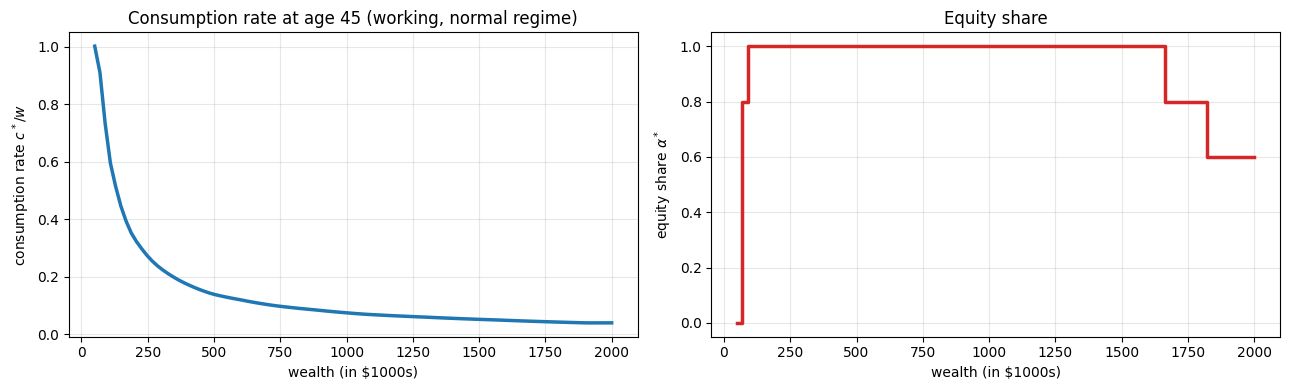

In [7]:
test_age = 45
w_grid = torch.linspace(50_000, 2_000_000, 100, dtype=torch.float64)
state_q = {
    "wealth": w_grid,
    "phase": torch.zeros(100, dtype=torch.long),       # working
    "regime": torch.full((100,), 2, dtype=torch.long), # normal regime
}
acts = policy(state_q, t=test_age)
c_star = acts["consume"].numpy()
eq_star = equity_share_t[acts["equity_share"]].numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(w_grid.numpy() / 1000, c_star / w_grid.numpy(), lw=2.5)
ax1.set_xlabel("wealth (in $1000s)")
ax1.set_ylabel("consumption rate $c^*/w$")
ax1.set_title(f"Consumption rate at age {test_age} (working, normal regime)")
ax1.grid(alpha=0.3)
ax2.step(w_grid.numpy() / 1000, eq_star, where="post", lw=2.5, color="C3")
ax2.set_xlabel("wealth (in $1000s)")
ax2.set_ylabel("equity share $\\alpha^*$")
ax2.set_title("Equity share")
ax2.set_ylim(-0.05, 1.05)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Optimal retirement boundary across age

For each age, the lowest wealth at which a still-working agent in the
normal regime chooses to retire. We expect the boundary to fall with
age — when there's lots of remaining horizon, retiring is only optimal
if you're very rich; near the end of life the boundary is much lower.

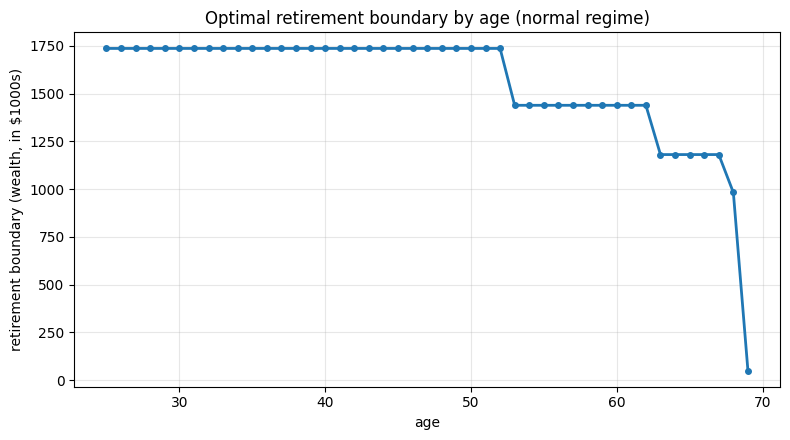

In [8]:
ages_for_boundary = range(MIN_AGE, int(MANDATORY_RETIREMENT_AGE))
w_search = torch.linspace(50_000, 4_000_000, 200, dtype=torch.float64)
boundary_w = []
for age in ages_for_boundary:
    state_q = {
        "wealth": w_search,
        "phase": torch.zeros(200, dtype=torch.long),
        "regime": torch.full((200,), 2, dtype=torch.long),
    }
    retire = policy(state_q, t=age)["retire"].numpy()
    idx = np.where(retire == 1)[0]
    boundary_w.append(w_search[idx[0]].item() if len(idx) > 0 else np.nan)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(ages_for_boundary), np.array(boundary_w) / 1000, "o-", lw=2, markersize=4)
ax.set_xlabel("age")
ax.set_ylabel("retirement boundary (wealth, in $1000s)")
ax.set_title("Optimal retirement boundary by age (normal regime)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Forward simulation

500 paths starting at age 25 with $50k in cash, working, in the normal
regime. Each path follows the optimal policy and the regime evolves
under $P$. Plot mean and quantile bands for wealth and consumption
over the lifecycle, plus the distribution of retirement ages.

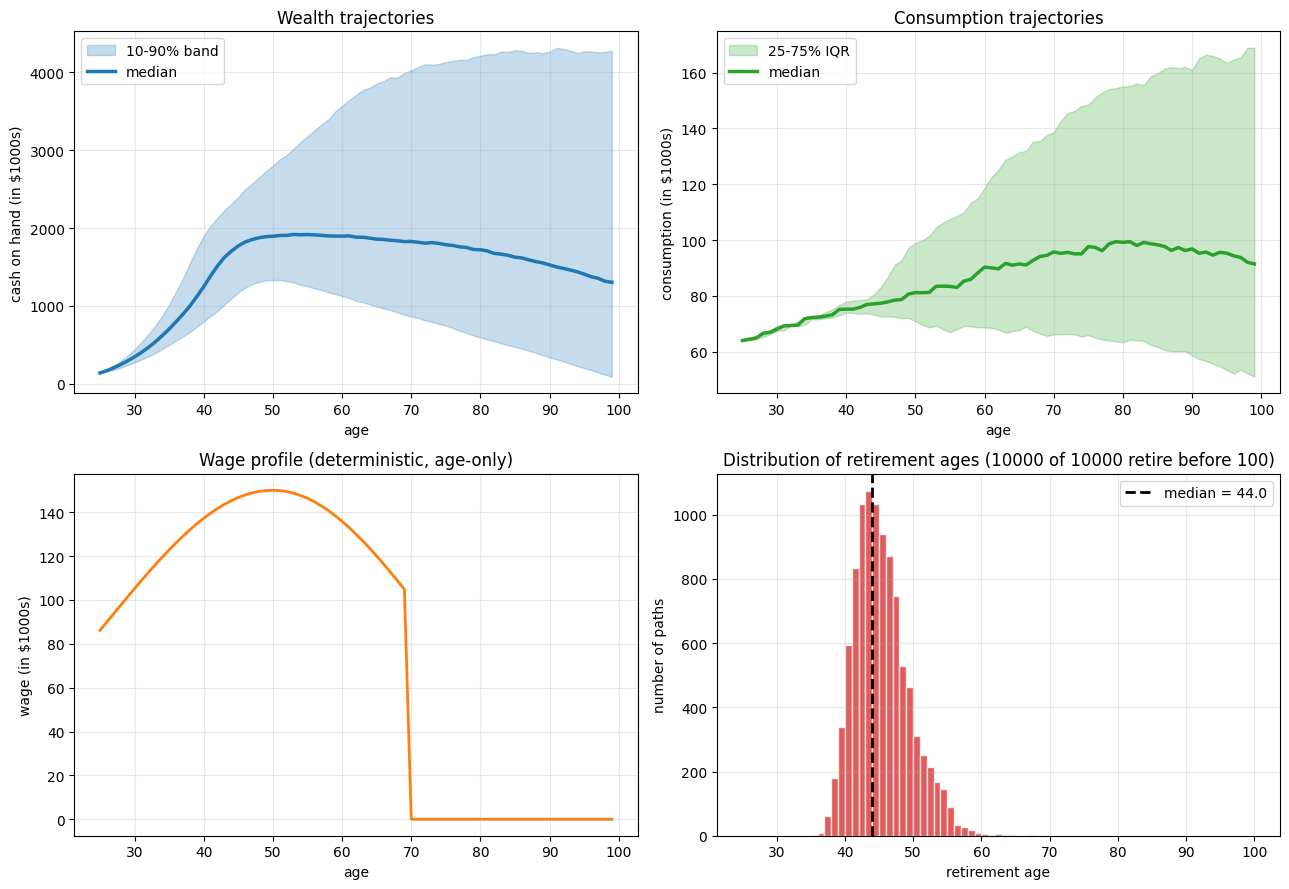

In [9]:
n_paths = 10_000
paths = simulate(
    policy=policy,
    problem=problem,
    n=n_paths,
    initial_state={
        "wealth": INITIAL_WEALTH,
        "phase": INITIAL_PHASE,
        "regime": INITIAL_REGIME,
    },
    seed=42,
)
paths_cpu = {k: v.cpu() for k, v in paths.items()}
wealth_paths = paths_cpu["wealth"].numpy()
consume_paths = paths_cpu["consume"].numpy()
phase_paths = paths_cpu["phase"].numpy()

# Find retirement age for each path
retirement_ages = np.full(n_paths, MAX_AGE)
for i in range(n_paths):
    retired = np.where(phase_paths[i] == 1)[0]
    if len(retired) > 0:
        retirement_ages[i] = MIN_AGE + retired[0]

age_axis = np.arange(MIN_AGE, MAX_AGE)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Wealth paths
ax = axes[0, 0]
ax.fill_between(
    age_axis,
    np.percentile(wealth_paths, 10, axis=0) / 1000,
    np.percentile(wealth_paths, 90, axis=0) / 1000,
    alpha=0.25, color="C0", label="10-90% band",
)
ax.plot(age_axis, np.median(wealth_paths, axis=0) / 1000, lw=2.5, color="C0", label="median")
ax.set_xlabel("age"); ax.set_ylabel("cash on hand (in $1000s)")
ax.set_title("Wealth trajectories")
ax.legend(); ax.grid(alpha=0.3)

# Consumption paths — show 25-75% IQR rather than 10-90% (the latter is
# dominated by regime extremes which makes the band look chaotic).
ax = axes[0, 1]
ax.fill_between(
    age_axis,
    np.percentile(consume_paths, 25, axis=0) / 1000,
    np.percentile(consume_paths, 75, axis=0) / 1000,
    alpha=0.25, color="C2", label="25-75% IQR",
)
ax.plot(age_axis, np.median(consume_paths, axis=0) / 1000, lw=2.5, color="C2", label="median")
ax.set_xlabel("age"); ax.set_ylabel("consumption (in $1000s)")
ax.set_title("Consumption trajectories")
ax.legend(); ax.grid(alpha=0.3)

# Wage curve (for reference)
ax = axes[1, 0]
wage_curve = np.array([wage_table[a].item() for a in age_axis])
ax.plot(age_axis, wage_curve / 1000, lw=2, color="C1")
ax.set_xlabel("age"); ax.set_ylabel("wage (in $1000s)")
ax.set_title("Wage profile (deterministic, age-only)")
ax.grid(alpha=0.3)

# Retirement age distribution
ax = axes[1, 1]
finite_retirements = retirement_ages[retirement_ages < MAX_AGE]
ax.hist(finite_retirements, bins=range(MIN_AGE, MAX_AGE + 1), color="C3", alpha=0.75, edgecolor="white")
ax.axvline(np.median(finite_retirements), color="black", lw=2, ls="--",
           label=f"median = {np.median(finite_retirements):.1f}")
ax.set_xlabel("retirement age")
ax.set_ylabel("number of paths")
ax.set_title(f"Distribution of retirement ages ({len(finite_retirements)} of {n_paths} retire before {MAX_AGE})")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary statistics

In [10]:
print(f"At age {MIN_AGE} with $${INITIAL_WEALTH/1000:.0f}k in normal regime, the median path:")
print(f"  median retirement age:   {np.median(finite_retirements):.0f}")
print(f"  median wealth at age 65: $${np.median(wealth_paths[:, 65 - MIN_AGE]) / 1000:.0f}k")
print(f"  median wealth at age 80: $${np.median(wealth_paths[:, 80 - MIN_AGE]) / 1000:.0f}k")
print(f"  fraction retiring by 65: {(finite_retirements <= 65).sum() / n_paths * 100:.0f}%")
print(f"  fraction never retiring: {(retirement_ages == MAX_AGE).sum() / n_paths * 100:.0f}%")

At age 25 with $$136k in normal regime, the median path:
  median retirement age:   44
  median wealth at age 65: $$1857k
  median wealth at age 80: $$1721k
  fraction retiring by 65: 100%
  fraction never retiring: 0%
